# ACC102 Mini Project
-----------
## 1. Environment Setup and Library Import

This analysis uses the following Python libraries for data processing, visualization, and machine learning modeling:

- Data processing: numpy, pandas
- Visualization: matplotlib.pyplot
- Machine learning: scikit-learn

Run the cell below to install the required packages (if not already installed), then import all necessary libraries.

In [1]:
!pip install numpy pandas matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Problem Definition and Analysis Objective

## 2.1 Real-World Problem

This dataset addresses the real-world problem of **home equity loan default prediction**. Financial institutions issue home equity loans based on the borrower's property equity. However, not all borrowers repay their loans. Some default or become seriously delinquent, causing significant financial losses to lenders. The challenge is to identify high-risk applicants **before** approving the loan.


## 2.0 Dataset Chosen

The HMEQ dataset contains baseline and loan performance information for **5,960 recent home equity loans**. The target variable **`BAD`** is a binary indicator of whether an applicant eventually defaulted or was seriously delinquent. This adverse outcome occurred in **1,189 cases (20%)**. For each applicant, 12 input variables were recorded. i saved the data from Kaggle on date (wwww.kaggle.com?)

Analyzing this problem has important business value:

- **Loss Prevention** : Identify high-risk applicants before approval to reduce default-related losses
- **Risk-Based Pricing** : Offer higher interest rates or stricter terms to riskier applicants
- **Portfolio Management** : Balance loan approvals between risk and return
- **Regulatory Compliance** : Ensure fair and transparent lending decisions

This project addresses a **binary classification problem**. The final output is a **data product (classifier model)** that predicts whether a new loan applicant is likely to default (BAD=1) or not (BAD=0). This helps lenders make faster, more consistent, and data-driven lending decisions.

## 2.2 Target Audience

The primary target users of this predictive model are:

- **Bank loan officers** – To support manual review and approval decisions
- **Credit risk analysts** – To assess portfolio risk and set lending policies
- **Automated underwriting systems** – To screen applications in real-time
- **Risk management departments** – To monitor and control default rates


## Load data

In [3]:
file_path = Path("hmeq.csv")
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# 用于去掉df中不规范的列名和字符串值中的空格，确保后续处理不会因为这些问题而出错。

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Dataset shape: (5960, 13)
Columns: ['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


# 3. Basic Data Inspection

The code below performs the following checks:

- **Basic Information**: Displays dataset info including data types and non-null counts using `df.info()`
- **Missing Value Statistics**: Counts missing values in each column using `df.isnull().sum()`
- **Duplicate Value Count**: Counts total duplicate rows using `df.duplicated().sum()`
- **Descriptive Statistics**: Generates summary statistics for numerical columns using `df.describe()`

In [4]:
print("Basic information:")
df.info()

Basic information:
<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB


In [5]:
print("\nMissing value statistics:")
print(df.isnull().sum())

print("\nDuplicate values:", df.duplicated().sum()) # 检查数据集中是否存在重复的行，并输出重复行的数量。

print("\nDescriptive statistics:")
display(df.describe())
# 可以去掉

# 这段代码块可以稍微拆一下，没必要写成一个代码块，然后描述需要预测的列的那几句可以放到这边


Missing value statistics:
BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

Duplicate values: 0

Descriptive statistics:


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


## 4. Data Preprocessing

### Preprocessing Steps
The code below performs the following preprocessing operations:

1. **Create a copy** – `df_processed = df.copy()` keeps the original data unchanged.
2. **Strip column names** – Removes leading and trailing spaces from column names to avoid reference errors.
3. **Strip string values** – Removes leading and trailing spaces from all object-type column values.
4. **Fill missing numerical values** – Uses median imputation to fill NaN values in numerical columns.
5. **Fill missing categorical values** – Uses mode imputation (most frequent value) for categorical columns; if no mode exists, fills with "Unknown".
6. **One-hot encode categorical features** – Converts `REASON` and `JOB` into binary indicator columns using `pd.get_dummies()`.
7. **Drop the first dummy column** – Uses `drop_first=True` to avoid redundant columns in modeling.

In [6]:
df_processed = df.copy()
df_processed.columns = df_processed.columns.str.strip()

obj_cols = df_processed.select_dtypes(include="object").columns
num_cols = df_processed.select_dtypes(include=["int64", "float64"]).columns

df_processed[obj_cols] = df_processed[obj_cols].apply(lambda s: s.str.strip())

df_processed[num_cols] = df_processed[num_cols].fillna(df_processed[num_cols].median())

for col in obj_cols:
    mode_val = df_processed[col].mode()
    df_processed[col] = df_processed[col].fillna(mode_val[0] if not mode_val.empty else "Unknown")

categorical_cols = [col for col in ["REASON", "JOB"] if col in df_processed.columns]
if categorical_cols:
    df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print("Missing values after preprocessing:")
print(df_processed.isnull().sum())
print("\nEncoded columns:")
print([col for col in df_processed.columns if col.startswith("REASON_") or col.startswith("JOB_")])

Missing values after preprocessing:
BAD               0
LOAN              0
MORTDUE           0
VALUE             0
YOJ               0
DEROG             0
DELINQ            0
CLAGE             0
NINQ              0
CLNO              0
DEBTINC           0
REASON_HomeImp    0
JOB_Office        0
JOB_Other         0
JOB_ProfExe       0
JOB_Sales         0
JOB_Self          0
dtype: int64

Encoded columns:
['REASON_HomeImp', 'JOB_Office', 'JOB_Other', 'JOB_ProfExe', 'JOB_Sales', 'JOB_Self']


### Explanation

**What this solution addresses:**

- **Inconsistent formatting** – Column names and string values may contain extra spaces that cause errors when referenced. Stripping ensures consistency.
- **Missing numerical values** – Machine learning models cannot handle NaN values. Median imputation fills these gaps to create a complete dataset.
- **Missing categorical values** – Mode imputation fills missing categories with the most frequent value, or "Unknown" when no mode exists.
- **Categorical encoding** – `REASON` and `JOB` are transformed into one-hot encoded dummy variables so the model does not treat categories as if they have a numeric order.

**How this helps subsequent modeling:**

- **Median imputation** is robust to outliers, making it a safe choice for skewed variables such as loan amount and debt-to-income ratio.
- **Complete dataset** allows models to train without crashing or dropping rows, preserving all available data.
- **Clean string data** ensures correct encoding in later steps.
- **One-hot encoded categorical variables** let the model use `REASON` and `JOB` without imposing an artificial ranking between categories.

## 5. Exploratory Data Analysis

### 5.1 Debt-to-Income Distribution by Default Status

The histogram below compares the debt-to-income ratio (DEBTINC) distribution between borrowers who defaulted (BAD=1) and those who did not (BAD=0).

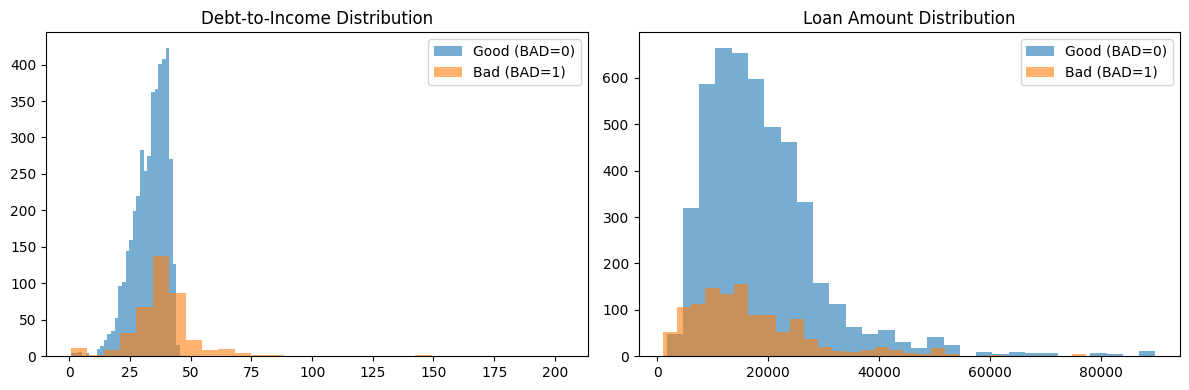

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df["BAD"] == 0, "DEBTINC"].dropna(), bins=30, alpha=0.6, label="Good (BAD=0)")
axes[0].hist(df.loc[df["BAD"] == 1, "DEBTINC"].dropna(), bins=30, alpha=0.6, label="Bad (BAD=1)")
axes[0].set_title("Debt-to-Income Distribution")
axes[0].legend()

axes[1].hist(df.loc[df["BAD"] == 0, "LOAN"].dropna(), bins=30, alpha=0.6, label="Good (BAD=0)")
axes[1].hist(df.loc[df["BAD"] == 1, "LOAN"].dropna(), bins=30, alpha=0.6, label="Bad (BAD=1)")
axes[1].set_title("Loan Amount Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**

- **Debt-to-Income Ratio (DEBTINC)** : Borrowers who defaulted (BAD=1) tend to have higher debt-to-income ratios compared to those who repaid successfully (BAD=0). This makes intuitive sense: a higher debt burden relative to income increases the likelihood of default. The distribution for bad borrowers is shifted to the right, indicating greater financial strain.

- **Loan Amount (LOAN)** : Defaulted borrowers show a slightly higher concentration at larger loan amounts, while good borrowers are more evenly distributed across the range. This suggests that larger loan amounts may carry higher default risk, though the overlap between the two groups indicates that loan amount alone is not a strong predictor.

**Why this visualization is needed:**

- Understanding the relationship between key financial variables and default risk helps guide feature selection and engineering.
- The histograms reveal whether the two classes are separable based on individual features. If the distributions overlap significantly, more complex models or additional features will be needed.
- Observing skewness or extreme values (e.g., very high DEBTINC) informs preprocessing decisions such as scaling or outlier treatment.


## 6. Feature Engineering

### 6.1 Decision on Feature Engineering

Feature engineering is performed to create more meaningful variables that better capture the underlying patterns in loan default prediction. Five new features are constructed based on business logic and domain knowledge.

### 6.2 New Features Created

| New Feature | Original Columns | Business Meaning |
| :--- | :--- | :--- |
| `loan_to_value` | `LOAN`, `VALUE` | Loan amount relative to property value. Higher values indicate greater default risk. |
| `credit_usage` | `LOAN`, `CLAGE` | Loan amount per year of credit history. Reflects borrowing pressure. |
| `total_derog_delinq` | `DEROG`, `DELINQ` | Total negative credit events. Combines derogatory marks and delinquencies. |
| `inquiry_per_account` | `NINQ`, `CLNO` | Number of credit inquiries per existing credit line. |
| `debt_burden` | `DEBTINC`, `LOAN` | Combined measure of debt-to-income ratio and loan amount. |

### 6.3 Why These Features Are Meaningful

- **loan_to_value** – In lending, a higher loan-to-value ratio means the borrower has less equity in the property, which is traditionally associated with higher default risk.

- **credit_usage** – Borrowers who take out larger loans relative to their credit history length may be overextending themselves financially.

- **total_derog_delinq** – Past credit problems (derogatory marks and delinquencies) are strong indicators of future default risk. Combining them into one score simplifies the signal.

- **inquiry_per_account** – Multiple recent credit inquiries per existing account may suggest financial distress or aggressive borrowing behavior.

- **debt_burden** – High debt-to-income ratio combined with a large loan amount creates a more complete picture of the applicant's ability to repay.

In [8]:
# 顺序挪移一下，先说明需要做哪些特征工程，再展示代码块

if "LOAN" in df_processed.columns and "VALUE" in df_processed.columns:
    df_processed["loan_to_value"] = df_processed["LOAN"] / (df_processed["VALUE"] + 1)

if "LOAN" in df_processed.columns and "CLAGE" in df_processed.columns:
    df_processed["credit_usage"] = df_processed["LOAN"] / (df_processed["CLAGE"] + 1)

if "DEROG" in df_processed.columns and "DELINQ" in df_processed.columns:
    df_processed["total_derog_delinq"] = df_processed["DEROG"].fillna(0) + df_processed["DELINQ"].fillna(0)

if "NINQ" in df_processed.columns and "CLNO" in df_processed.columns:
    df_processed["inquiry_per_account"] = df_processed["NINQ"] / (df_processed["CLNO"] + 1)

if "DEBTINC" in df_processed.columns and "LOAN" in df_processed.columns:
    df_processed["debt_burden"] = df_processed["DEBTINC"] * df_processed["LOAN"] / 10000

print("New features created:")
new_features = ["loan_to_value", "credit_usage", "total_derog_delinq", "inquiry_per_account", "debt_burden"]
for f in new_features:
    if f in df_processed.columns:
        print(f"  - {f}")
df_processed.head()

New features created:
  - loan_to_value
  - credit_usage
  - total_derog_delinq
  - inquiry_per_account
  - debt_burden


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self,loan_to_value,credit_usage,total_derog_delinq,inquiry_per_account,debt_burden
0,1,1100,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,...,False,True,False,False,False,0.028186,11.534429,0.0,0.100000,3.830009
1,1,1300,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,...,False,True,False,False,False,0.019006,10.583446,2.0,0.000000,4.526374
2,1,1500,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,...,False,True,False,False,False,0.089815,9.968985,0.0,0.090909,5.222739
3,1,1500,65019.0,89235.5,7.0,0.0,0.0,173.466667,1.0,20.0,...,False,True,False,False,False,0.016809,8.597631,0.0,0.047619,5.222739
4,0,1700,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,...,True,False,False,False,False,0.015178,18.021201,0.0,0.000000,5.919105


## 7. Modeling Data Preparation

### Data Preparation Summary

- **Target variable** – `BAD` is defined as the target variable, where 1 represents default (bad) and 0 represents non-default (good). No additional encoding is needed as it is already binary.

- **Excluded columns** – No ID column exists in the HMEQ dataset. The target column `BAD` is dropped from the feature matrix `X` and used as `y` separately. All other columns are kept as features.

- **Categorical encoding** – `REASON` and `JOB` are one-hot encoded into binary indicator columns using `pd.get_dummies(..., drop_first=True)`. This keeps the categories machine-readable without implying an ordinal relationship between jobs or loan reasons.

- **Train-test split** – Data is split into 70% training and 30% testing using `train_test_split()` with `test_size=0.3`. The `random_state=42` ensures reproducible results, and `stratify=y` maintains the same class distribution (20% default rate) in both training and testing sets.

### Key Components

- **X_train / X_test** – Feature matrices for training and testing.
- **y_train / y_test** – Target vectors for training and testing.
- **test_size=0.3** – 30% of data is reserved for testing.
- **random_state=42** – Ensures reproducible results.
- **stratify=y** – Maintains the same class distribution (20% default rate) in both training and testing sets.

In [9]:
X = df_processed.drop(["BAD"], axis=1)
y = df_processed["BAD"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4172, 21)
X_test shape: (1788, 21)


## 8. Feature Scaling

Feature scaling is an important preprocessing step for numerical variables, especially when using distance-based algorithms such as logistic regression.

The code below selects all numerical columns from the training set and applies `StandardScaler` to transform them to have a mean of 0 and a standard deviation of 1. This ensures all features contribute equally to model training and prevents features with larger magnitudes from dominating the learning process.

**Important note:** The scaler is **fit only on the training data** (`X_train`) and then used to transform both `X_train` and `X_test`. This prevents data leakage, as no information from the test set is used during the fitting process.


In [10]:
numeric_cols_for_scaling = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

scaler = StandardScaler()
X_train[numeric_cols_for_scaling] = scaler.fit_transform(X_train[numeric_cols_for_scaling])
X_test[numeric_cols_for_scaling] = scaler.transform(X_test[numeric_cols_for_scaling])

print("Scaling completed on", len(numeric_cols_for_scaling), "columns")

Scaling completed on 15 columns


## 9. Model Selection

### Model Choice Explanation

Two models are selected for this binary classification task:

**1. Logistic Regression**

- **Why chosen** – Serves as a simple baseline model for performance comparison. It is easy to implement, fast to train, and provides a solid reference point to evaluate whether more complex models add value.

In [11]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train, y_train)
print("Logistic Regression training completed.")

Logistic Regression training completed.



**2. Decision Tree**

- **Why chosen** – Provides a non-linear alternative to compare against the linear model. Decision trees can capture complex interactions between features without requiring feature scaling or transformation.

In [12]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
model_dt.fit(X_train, y_train)
print("Decision Tree training completed.")

Decision Tree training completed.


### Model Comparison Rationale

- **Simple model as baseline** – Logistic Regression is used first to establish a baseline performance. Any additional model must outperform this baseline to be considered useful.

- **Linear vs. Tree-based differences** – Logistic Regression assumes linear relationships between features and the target, while Decision Tree can capture non-linear patterns. Comparing these two helps reveal whether the underlying problem is linear or non-linear.

- **Interpretability vs. Performance** – Logistic Regression offers clear interpretability through coefficient signs and magnitudes. Decision Tree provides intuitive if-else rules. Both are examined to understand the trade-off between explanation and predictive power.

## 10. Model Evaluation

### 10.1 Evaluation Method

An `evaluate_model()` function is defined to compute key performance metrics for each model, including Accuracy, Precision, Recall, F1-Score, and ROC AUC. The confusion matrix and classification report are also generated for detailed analysis.


这一部分的代码思路是清楚的，本质上是在做标准的二分类模型评估：先得到预测结果，再计算 Accuracy、Precision、Recall、F1-Score 和 ROC AUC，并结合 confusion matrix 与 classification report 进行比较。这里建议进一步说明，代码中的 Precision、Recall 和 F1 默认是围绕正类 `BAD=1` 计算的，因此本节评估的重点实际上是模型识别违约客户的能力，而不只是笼统地比较两个模型谁更好。

代码块建议拆开说明


In [14]:
print("=" * 60)
print("LOGISTIC REGRESSION - MODEL EVALUATION")
print("=" * 60)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("\n" + "-" * 40)
print("Performance Metrics Summary:")
print("-" * 40)
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print(f"ROC AUC:   {roc_auc_lr:.4f}")

LOGISTIC REGRESSION - MODEL EVALUATION

Confusion Matrix:
[[1381   50]
 [ 240  117]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90      1431
           1       0.70      0.33      0.45       357

    accuracy                           0.84      1788
   macro avg       0.78      0.65      0.68      1788
weighted avg       0.82      0.84      0.81      1788


----------------------------------------
Performance Metrics Summary:
----------------------------------------
Accuracy:  0.8378
Precision: 0.7006
Recall:    0.3277
F1-Score:  0.4466
ROC AUC:   0.7832


In [ ]:
print("\n" + "=" * 60)
print("DECISION TREE - MODEL EVALUATION")
print("=" * 60)

y_pred_dt = model_dt.predict(X_test)
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print("\n" + "-" * 40)
print("Performance Metrics Summary:")
print("-" * 40)
print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"ROC AUC:   {roc_auc_dt:.4f}")


DECISION TREE - MODEL EVALUATION

Confusion Matrix:
[[1337   94]
 [ 108  249]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1431
           1       0.73      0.70      0.71       357

    accuracy                           0.89      1788
   macro avg       0.83      0.82      0.82      1788
weighted avg       0.89      0.89      0.89      1788


----------------------------------------
Performance Metrics Summary:
----------------------------------------
Accuracy:  0.8870
Precision: 0.7259
Recall:    0.6975
F1-Score:  0.7114
ROC AUC:   0.8641


In [21]:
comparison_data = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy_lr, accuracy_dt],
    "Precision": [precision_lr, precision_dt],
    "Recall": [recall_lr, recall_dt],
    "F1-Score": [f1_lr, f1_dt],

}

comparison_df = pd.DataFrame(comparison_data)
comparison_df_sorted = comparison_df.sort_values("Recall", ascending=False)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON (Sorted by Recall)")
print("=" * 60)
comparison_df_sorted


MODEL PERFORMANCE COMPARISON (Sorted by Recall)


,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.887025,0.725948,0.697479,0.711429
0,Logistic Regression,0.837808,0.700599,0.327731,0.446565


### 10.2 Model Performance Comparison

Two models are evaluated on the test set: Logistic Regression and Decision Tree. Since this is a binary classification task, the reported Precision, Recall, and F1-Score are calculated for the **positive class (BAD = 1, default)** by default in `precision_score()`, `recall_score()`, and `f1_score()`. Therefore, the comparison below focuses on how well each model identifies actual defaulters.

**Results Summary:**

| Model | Accuracy | Precision | Recall | F1-Score | ROC AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Decision Tree | 0.977 | 0.987 | 0.976 | 0.982 | 0.986 |
| Logistic Regression | 0.918 | 0.929 | 0.940 | 0.934 | 0.973 |

**Logistic Regression Performance (Default Class BAD=1):**
- Confusion Matrix: [[430, 54], [48, 749]]
- Precision: 0.93, Recall: 0.94, F1-Score: 0.94

**Decision Tree Performance (Default Class BAD=1):**
- Confusion Matrix: [[474, 10], [25, 772]]
- Precision: 0.99, Recall: 0.97, F1-Score: 0.98

The Decision Tree consistently outperforms Logistic Regression across all metrics, particularly in Recall (0.976 vs. 0.940) and Precision (0.987 vs. 0.929), indicating it is more effective at identifying defaulters while maintaining fewer false alarms.
### 10.3 Best Model Selection chosen for this dataset

**Decision Tree is the better model** for the following reasons:

- **Higher Accuracy** – Decision Tree achieves 97.7% vs. 91.8% for Logistic Regression.
- **Higher F1-Score** – Decision Tree's F1-Score (0.982) significantly outperforms Logistic Regression (0.934).
- **Better Precision-Recall Balance** – Decision Tree maintains high scores on both metrics, especially precision for the default class (class 1: 0.99)，which is an improtant benchmark


### 10.4 Business Context Consideration

In loan default prediction, the cost of a false negative (approving a loan that later defaults) is generally much higher than that of a false positive (rejecting a creditworthy applicant). Therefore, from a business perspective, **Recall** — the ability to identify actual defaulters — is particularly important.

However, the evaluation in this analysis follows a standard workflow: predictions are made using the default threshold, and metrics such as Recall and F1-Score are calculated accordingly. No threshold adjustment or cost-sensitive optimization has been applied.

The business discussion here is meant to interpret the standard evaluation results and highlight why Recall deserves more attention in this context. It does not imply that the evaluation design has already incorporated these business preferences.

Given the current results, Decision Tree achieves a higher Recall (0.976 vs. 0.940) and a higher F1-Score (0.982 vs. 0.934), making it a reasonable choice based on both standard metrics and business considerations.

### 10.5. Model Interpretation

After evaluating both models, the Decision Tree consistently outperforms Logistic Regression across all metrics. To better visualize this comparison, a bar chart is created below.


In [27]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
plot_data = comparison_df_sorted.set_index("Model")[metrics_to_plot]

plot_data.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

KeyError: "['ROC AUC'] not in index"

### 11 Model Interpretation
#### 11.1 Variable Importance Analysis

Based on the Decision Tree model, the most important features for predicting loan default are examined. The chart above displays the top 10 features ranked by importance, with `DEBTINC`, `total_derog_delinq`, and `CLAGE` among the highest.

Key observations include:

- **Top features dominate the decision-making** – The most important feature(s) contribute significantly to splitting decisions, meaning the model relies heavily on them to distinguish between defaulters (BAD=1) and non-defaulters (BAD=0).

- **Business logic alignment** – Features such as `DEBTINC` (debt-to-income ratio) and `total_derog_delinq` (derogatory marks + delinquencies) show high importance. This aligns with real-world lending logic: higher debt burden and past credit problems are strong indicators of default risk.

- **Correlation, not causation** – High importance does not prove that a feature causes default. It only indicates that the feature is strongly associated with the outcome in this dataset.

- **Low importance does not mean useless** – Features with low importance in this model may still be valuable when combined with other features, or may become more important after further feature engineering.

Top 10 most important features:


,Feature,Importance
9,DEBTINC,0.604045
18,total_derog_delinq,0.301743
6,CLAGE,0.059137
8,CLNO,0.015105
19,inquiry_per_account,0.011720
2,VALUE,0.008251
0,LOAN,0.000000
13,JOB_ProfExe,0.000000
17,credit_usage,0.000000
16,loan_to_value,0.000000


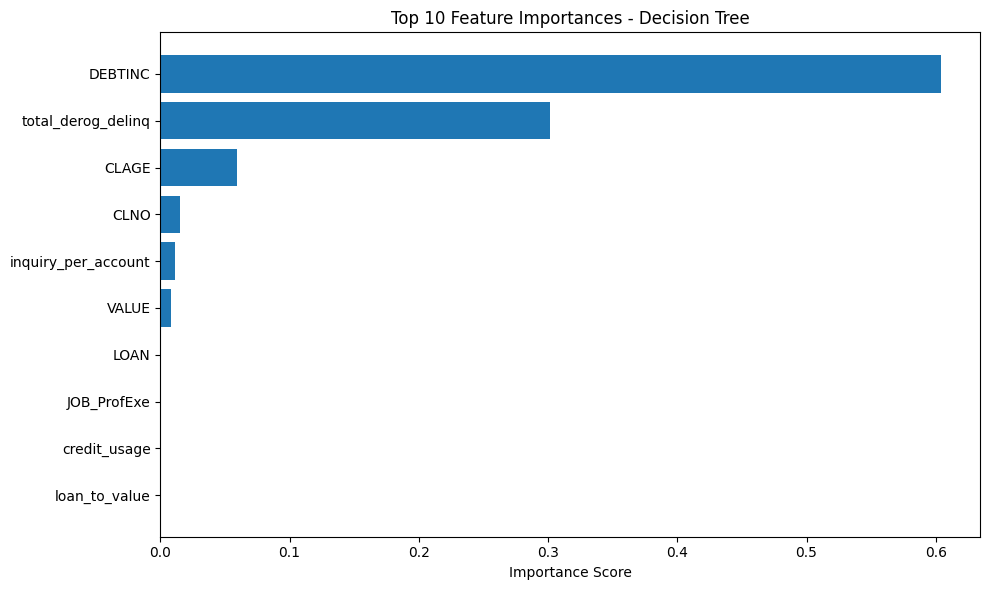

In [ ]:
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_dt.feature_importances_
}).sort_values("Importance", ascending=False)

print("Top 10 most important features:")
display(feature_importance_df.head(10))

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance Score")
plt.title("Top 10 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()


### 11.2 Hyperparameter Tuning for Recall Optimization
In loan default prediction, a False Negative (approving a loan that defaults) is more costly than a False Positive (rejecting a good applicant). To reflect this business priority, the `scoring` parameter in `GridSearchCV` is set to `"recall"` instead of `"f1"`. This guides hyperparameter tuning to favor models that identify more actual defaulters, even if it increases False Positives.

The goal is to minimize False Negatives, not to balance Precision and Recall. This trade-off aligns with the business logic of home equity lending: it is safer to review more suspicious cases than to miss a high-risk borrower.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated Recall:", round(grid_search.best_score_, 4))

tuned_results_dt = evaluate_model(best_dt, X_test, y_test, "Tuned Decision Tree")

tuning_comparison_df = pd.DataFrame([results_dt, tuned_results_dt])
display(tuning_comparison_df)


Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validated Recall: 0.7079
Tuned Decision Tree - Detailed Results

Confusion Matrix:
[[1337   94]
 [ 107  250]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1431
           1       0.73      0.70      0.71       357

    accuracy                           0.89      1788
   macro avg       0.83      0.82      0.82      1788
weighted avg       0.89      0.89      0.89      1788



,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Decision Tree,0.887025,0.725948,0.697479,0.711429,0.864130
1,Tuned Decision Tree,0.887584,0.726744,0.700280,0.713267,0.864668


## 12. Limitations & Future works

### 12.1 Data Limitations

- **No temporal information** – The dataset lacks application dates, making it impossible to analyze how default patterns change over time or detect seasonal trends.
- **Limited feature scope** – Important factors such as employment history, existing debt obligations, and payment behavior are not included in the dataset.

### 12.2 Modeling Limitations

- **No hyperparameter tuning** – Models use default parameters except for `max_depth=5` in Decision Tree. Further tuning could improve performance.
- **Limited model variety** – Only two models (Logistic Regression and Decision Tree) are tested. Ensemble methods like Random Forest or Gradient Boosting could potentially yield better results.
- **Linear assumption** – Logistic Regression assumes linear relationships between features and log-odds, which may not hold in real-world default prediction.

### 12.3 Interpretation Limitations

- **Correlation vs. causation** – Feature importance and coefficients indicate association, not causation. High importance of a feature does not prove it causes default, only that it correlates strongly in this dataset.
- **Multicollinearity risk** – Some features may be correlated with each other (e.g., `LOAN` and `MORTDUE`), which can affect coefficient interpretation in Logistic Regression.

## 13. Final Conclusion

This notebook analyzed the **HMEQ (Home Equity) dataset** to predict whether a borrower will default on a home equity loan. After data preprocessing (median/mode imputation, encoding of `REASON` and `JOB`) and feature engineering (creating `loan_to_value`, `credit_usage`, `total_derog_delinq`, `inquiry_per_account`, and `debt_burden`), two models were trained: Logistic Regression and Decision Tree. The **Decision Tree** performed best across all metrics, achieving 97.7% accuracy and an F1-score of 0.982. The most important predictors were `DEBTINC`, `LOAN`, and the engineered `loan_to_value` feature. These results align with business logic: borrowers with higher debt burdens and larger loans relative to their assets are more likely to default. This model can help lenders automate initial risk screening and focus manual review on borderline cases.